In [ ]:
import pandas as pd
import numpy as np
import os
import logging
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted successfully!")
print("✓ Your files are now available at /content/drive/My Drive/")

Mounted at /content/drive
✓ Google Drive mounted successfully!
✓ Your files are now available at /content/drive/My Drive/


In [ ]:
import os
import sys
from pathlib import Path

# Define base paths for Colab
COLAB_PROJECT_ROOT = Path("/content/drive/My Drive/godavari_gnn_project")

In [ ]:
import pandas as pd
import numpy as np
import os
import logging
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def load_nwis_data(file_path, data_type):
    """Load NWIS Excel files with proper header handling and date parsing"""
    try:
        # Read the Excel file without headers first to find data start
        df_raw = pd.read_excel(file_path, header=None)

        # Find the row where actual data starts (look for 'Data Type Code' header)
        data_start_row = None
        for idx, row in df_raw.iterrows():
            # Convert all row values to string for a robust search, as values can be mixed types
            if 'Data Type Code' in [str(x) for x in row.values]:
                data_start_row = idx
                break

        if data_start_row is None:
            print(f"⚠️  Could not find 'Data Type Code' header in {file_path.name}. Trying alternative patterns.")
            # Try to find alternative header patterns if primary is not found
            for idx, row in df_raw.iterrows():
                if any(col in [str(x) for x in row.values] for col in ['Data Time', 'Data Value', 'Unit']):
                    data_start_row = idx
                    break

        if data_start_row is not None:
            # Read data with proper header
            df = pd.read_excel(file_path, header=data_start_row)
            print(f"✅ Data starts at row {data_start_row + 1} in {file_path.name}")

            # Ensure 'Data Time' column is in datetime format
            if 'Data Time' in df.columns:
                # Coerce errors will turn unparseable dates into NaT (Not a Time)
                df['Data Time'] = pd.to_datetime(df['Data Time'], errors='coerce')
                # Drop rows where 'Data Time' could not be parsed (is NaT)
                df.dropna(subset=['Data Time'], inplace=True)

                if df['Data Time'].empty and not df.empty:
                    print(f"❌ No valid 'Data Time' entries left after parsing and cleaning for {file_path.name}.")
                    return None
                elif df.empty:
                    print(f"❌ DataFrame became empty after cleaning 'Data Time' for {file_path.name}.")
                    return None
            else:
                print(f"⚠️  'Data Time' column not found in {file_path.name} after header detection. Data might be incomplete.")
                # If 'Data Time' is critical and missing, you might want to return None here
                # For now, we'll proceed but this might lead to errors downstream if 'Data Time' is expected.

            return df
        else:
            print(f"❌ No data header found in {file_path.name}. Cannot load data.")
            return None

    except Exception as e:
        print(f"❌ Error reading {file_path.name}: {e}")
        return None

def load_lake_data(lake_name):
    """Load all data files for a specific lake with NWIS format handling"""
    lake_path = COLAB_PROJECT_ROOT / 'data' / 'raw' / lake_name.lower()

    data_dict = {}

    try:
        # Define exact file names
        file_patterns = {
            'rainfall': f'Rainfall_{lake_name.capitalize()}.xlsx',
            'humidity': f'Relative-Humidity_{lake_name.capitalize()}.xlsx',
            'water_level': f'River-Water-Level_{lake_name.capitalize()}.xlsx',
            'discharge': f'River-Water-Discharge_{lake_name.capitalize()}.xlsx'
        }

        # Load each file
        for data_type, filename in file_patterns.items():
            file_path = lake_path / filename
            if file_path.exists():
                df = load_nwis_data(file_path, data_type) # Call load_nwis_data here
                if df is not None:
                    data_dict[data_type] = df
                    print(f"✅ Loaded {data_type} data for {lake_name}")
                else:
                    print(f"⚠️  Could not process {data_type} data for {lake_name}")
            else:
                print(f"⚠️  File not found: {file_path}")

    except Exception as e:
        print(f"❌ Error loading data for {lake_name}: {e}")

    return data_dict

# Test with updated loader
print("Loading Adhala data with NWIS format handling...")
adhala_data = load_lake_data('adhala')
print(f"Adhala data keys: {list(adhala_data.keys())}")

# Check the structure after proper loading
if 'rainfall' in adhala_data and adhala_data['rainfall'] is not None:
    print("\n📊 Rainfall data structure after proper loading:")
    print(adhala_data['rainfall'].head())
    print(f"Columns: {list(adhala_data['rainfall'].columns)}")
    print(f"Shape: {adhala_data['rainfall'].shape}")
else:
    print("\n⚠️ Rainfall data not loaded or is empty.")


Loading Adhala data with NWIS format handling...
✅ Data starts at row 7 in Rainfall_Adhala.xlsx
✅ Loaded rainfall data for adhala
✅ Data starts at row 7 in Relative-Humidity_Adhala.xlsx
✅ Loaded humidity data for adhala
✅ Data starts at row 7 in River-Water-Level_Adhala.xlsx
✅ Loaded water_level data for adhala
✅ Data starts at row 7 in River-Water-Discharge_Adhala.xlsx
✅ Loaded discharge data for adhala
Adhala data keys: ['rainfall', 'humidity', 'water_level', 'discharge']

📊 Rainfall data structure after proper loading:
  Data Type Code                       Data Type Description  \
0            MPS  MANUAL-Rainfall - SRG(Standard Rain Gauge)   
1            MPS  MANUAL-Rainfall - SRG(Standard Rain Gauge)   
2            MPS  MANUAL-Rainfall - SRG(Standard Rain Gauge)   
3            MPS  MANUAL-Rainfall - SRG(Standard Rain Gauge)   
4            MPS  MANUAL-Rainfall - SRG(Standard Rain Gauge)   

            Data Time  Data Value Unit  
0 2021-06-01 08:30:00         0.0   mm  
1 202

In [ ]:
def process_all_lakes():
    """Process all 6 lakes in one go"""
    lakes = ['adhala', 'girija', 'indravati', 'manjira', 'valamuru', 'sabari']

    all_lakes_data = {}

    print("🚀 STARTING BATCH PROCESSING FOR ALL 6 LAKES")
    print("=" * 60)

    for lake_name in lakes:
        print(f"\n{'='*50}")
        print(f"🌊 PROCESSING: {lake_name.upper()}")
        print(f"{'='*50}")

        # Load data for this lake
        lake_data = load_lake_data(lake_name)

        if lake_data:
            all_lakes_data[lake_name] = lake_data
            print(f"✅ SUCCESS: Loaded {len(lake_data)} data types for {lake_name}")

            # Show data structure for each data type
            for data_type, df in lake_data.items():
                print(f"   📊 {data_type}: {df.shape[0]} rows, {df.shape[1]} columns")
                print(f"   📅 Date range: {df['Data Time'].min()} to {df['Data Time'].max()}")
        else:
            print(f"❌ FAILED: No data loaded for {lake_name}")

    # Final summary
    print(f"\n{'='*60}")
    print("📊 BATCH PROCESSING SUMMARY")
    print(f"{'='*60}")
    print(f"✅ Successfully processed: {len(all_lakes_data)} out of {len(lakes)} lakes")

    successful_lakes = list(all_lakes_data.keys())
    failed_lakes = [lake for lake in lakes if lake not in successful_lakes]

    if successful_lakes:
        print(f"🎯 Successful lakes: {', '.join(successful_lakes)}")
    if failed_lakes:
        print(f"⚠️  Failed lakes: {', '.join(failed_lakes)}")

    # Show detailed breakdown
    print(f"\n📈 DETAILED BREAKDOWN:")
    for lake_name, lake_data in all_lakes_data.items():
        data_types = list(lake_data.keys())
        total_rows = sum([df.shape[0] for df in lake_data.values()])
        print(f"   🌊 {lake_name}: {len(data_types)} data types, {total_rows} total records")
        for data_type, df in lake_data.items():
            date_range = f"{df['Data Time'].min().strftime('%Y-%m-%d')} to {df['Data Time'].max().strftime('%Y-%m-%d')}"
            print(f"      • {data_type}: {df.shape[0]} records ({date_range})")

    return all_lakes_data

# Run the batch processing
print("Starting batch processing for all lakes...")
all_lakes_raw_data = process_all_lakes()


Starting batch processing for all lakes...
🚀 STARTING BATCH PROCESSING FOR ALL 6 LAKES

🌊 PROCESSING: ADHALA
✅ Data starts at row 7 in Rainfall_Adhala.xlsx
✅ Loaded rainfall data for adhala
✅ Data starts at row 7 in Relative-Humidity_Adhala.xlsx
✅ Loaded humidity data for adhala
✅ Data starts at row 7 in River-Water-Level_Adhala.xlsx
✅ Loaded water_level data for adhala
✅ Data starts at row 7 in River-Water-Discharge_Adhala.xlsx
✅ Loaded discharge data for adhala
✅ SUCCESS: Loaded 4 data types for adhala
   📊 rainfall: 306 rows, 5 columns
   📅 Date range: 2021-06-01 08:30:00 to 2022-10-31 08:30:00
   📊 humidity: 1340 rows, 5 columns
   📅 Date range: 2020-01-01 08:30:00 to 2021-10-31 17:30:00
   📊 water_level: 1135 rows, 5 columns
   📅 Date range: 2020-01-01 08:30:00 to 2021-10-31 17:30:00
   📊 discharge: 608 rows, 5 columns
   📅 Date range: 2020-06-01 08:30:00 to 2021-10-31 17:30:00

🌊 PROCESSING: GIRIJA
✅ Data starts at row 7 in Rainfall_Girija.xlsx
✅ Loaded rainfall data for girija
✅

#Cleaning and feature engineering

In [ ]:
def clean_and_merge_lake_data(all_lakes_raw_data):
    """Clean the raw data and create unified time-series features"""
    all_lakes_processed = {}

    for lake_name, lake_data in all_lakes_raw_data.items():
        print(f"\n🔄 Processing {lake_name.upper()}...")

        processed_dfs = []

        for data_type, df in lake_data.items():
            print(f"   Cleaning {data_type}...")

            # Clean and standardize
            df_clean = clean_nwis_data(df, data_type, lake_name)
            if df_clean is not None:
                processed_dfs.append(df_clean)

        # Merge all parameters for this lake
        if processed_dfs:
            merged_df = processed_dfs[0]
            for df in processed_dfs[1:]:
                merged_df = merged_df.join(df, how='outer')

            # Add temporal features
            merged_df = add_temporal_features(merged_df, lake_name)
            all_lakes_processed[lake_name] = merged_df

            print(f"✅ {lake_name}: {len(merged_df)} days, {len(merged_df.columns)} features")
        else:
            print(f"❌ {lake_name}: No valid data after cleaning")

    return all_lakes_processed

def clean_nwis_data(df, data_type, lake_name):
    """Clean individual NWIS dataset"""
    try:
        # Keep only essential columns
        if 'Data Time' not in df.columns or 'Data Value' not in df.columns:
            print(f"⚠️  {lake_name} {data_type}: Missing required columns")
            return None

        df_clean = df[['Data Time', 'Data Value']].copy()
        df_clean.columns = ['timestamp', 'value']

        # Convert to datetime and numeric
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['value'] = pd.to_numeric(df_clean['value'], errors='coerce')

        # Remove invalid data
        df_clean = df_clean.dropna()

        # Set index and resample to daily
        df_clean = df_clean.set_index('timestamp')
        df_daily = df_clean.resample('D').mean()

        # Create column name based on data type
        col_name = {
            'rainfall': 'rainfall_mm',
            'humidity': 'humidity_pct',
            'water_level': 'water_level_m',
            'discharge': 'discharge_m3s'
        }.get(data_type, data_type)

        df_daily.columns = [col_name]

        return df_daily

    except Exception as e:
        print(f"❌ Error cleaning {lake_name} {data_type}: {e}")
        return None

def add_temporal_features(df, lake_name):
    """Add temporal and derived features"""
    df_enhanced = df.copy()

    # Basic temporal features
    df_enhanced['day_of_year'] = df_enhanced.index.dayofyear
    df_enhanced['month'] = df_enhanced.index.month
    df_enhanced['year'] = df_enhanced.index.year

    # Seasonal encoding
    df_enhanced['day_sin'] = np.sin(2 * np.pi * df_enhanced['day_of_year'] / 365)
    df_enhanced['day_cos'] = np.cos(2 * np.pi * df_enhanced['day_of_year'] / 365)

    # Monsoon indicator (June-Sept)
    df_enhanced['is_monsoon'] = ((df_enhanced.index.month >= 6) &
                                (df_enhanced.index.month <= 9)).astype(int)

    # Rate of change features
    if 'water_level_m' in df_enhanced.columns:
        df_enhanced['water_level_change'] = df_enhanced['water_level_m'].diff()
        df_enhanced['water_level_change_3d'] = df_enhanced['water_level_m'].diff(3)

    if 'rainfall_mm' in df_enhanced.columns:
        df_enhanced['rainfall_3d_sum'] = df_enhanced['rainfall_mm'].rolling(3).sum()
        df_enhanced['rainfall_7d_sum'] = df_enhanced['rainfall_mm'].rolling(7).sum()

    if 'discharge_m3s' in df_enhanced.columns:
        df_enhanced['discharge_change'] = df_enhanced['discharge_m3s'].diff()

    print(f"   Added {len(df_enhanced.columns) - len(df.columns)} temporal features")
    return df_enhanced

# Process the data
print("🔄 Cleaning and feature engineering...")
all_lakes_processed = clean_and_merge_lake_data(all_lakes_raw_data)

#Step 2: Handle Missing Data & Normalization

In [ ]:
def handle_missing_data(all_lakes_processed):
    """Intelligently handle missing values"""
    from sklearn.preprocessing import StandardScaler

    all_lakes_cleaned = {}
    scalers = {}

    for lake_name, df in all_lakes_processed.items():
        df_clean = df.copy()

        print(f"\n🧹 Cleaning {lake_name}...")

        # Handle missing values with different strategies
        for column in df_clean.columns:
            if df_clean[column].isnull().any():
                missing_count = df_clean[column].isnull().sum()

                if 'water_level' in column or 'discharge' in column:
                    df_clean[column] = df_clean[column].fillna(method='ffill').interpolate()
                elif 'rainfall' in column:
                    df_clean[column] = df_clean[column].fillna(0).interpolate()
                else:
                    df_clean[column] = df_clean[column].interpolate()

                print(f"   ✅ {column}: Fixed {missing_count} missing values")

        # Final cleanup
        df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')

        # Normalize features (except temporal ones)
        non_temporal_cols = [col for col in df_clean.columns if col not in
                           ['day_of_year', 'month', 'year', 'day_sin', 'day_cos', 'is_monsoon']]

        scaler = StandardScaler()
        df_clean[non_temporal_cols] = scaler.fit_transform(df_clean[non_temporal_cols])
        scalers[lake_name] = scaler

        all_lakes_cleaned[lake_name] = df_clean

    return all_lakes_cleaned, scalers

# Clean and normalize
print("\n🧹 Handling missing values and normalization...")
all_lakes_cleaned, scalers = handle_missing_data(all_lakes_processed)


🧹 Handling missing values and normalization...

🧹 Cleaning adhala...
   ✅ rainfall_mm: Fixed 729 missing values
   ✅ humidity_pct: Fixed 365 missing values
   ✅ water_level_m: Fixed 457 missing values
   ✅ discharge_m3s: Fixed 729 missing values
   ✅ water_level_change: Fixed 459 missing values
   ✅ water_level_change_3d: Fixed 463 missing values
   ✅ rainfall_3d_sum: Fixed 733 missing values
   ✅ rainfall_7d_sum: Fixed 741 missing values
   ✅ discharge_change: Fixed 731 missing values

🧹 Cleaning girija...
   ✅ rainfall_mm: Fixed 585 missing values
   ✅ discharge_m3s: Fixed 49 missing values
   ✅ water_level_change: Fixed 1 missing values
   ✅ water_level_change_3d: Fixed 3 missing values
   ✅ rainfall_3d_sum: Fixed 589 missing values
   ✅ rainfall_7d_sum: Fixed 597 missing values
   ✅ discharge_change: Fixed 72 missing values

🧹 Cleaning indravati...
   ✅ rainfall_mm: Fixed 620 missing values
   ✅ humidity_pct: Fixed 83 missing values
   ✅ water_level_m: Fixed 43 missing values
   ✅

#Step 3: Graph Construction

In [ ]:
import torch

def build_complete_lake_graph():
    """Build complete graph structure for all 6 lakes in Godavari Basin"""

    # Node mapping - all 6 lakes with their positions
    node_mapping = {
        0: 'adhala',      # Upper Basin
        1: 'girija',      # Upper Basin
        2: 'indravati',   # Middle Basin
        3: 'manjira',     # Middle Basin
        4: 'valamuru',    # Lower Basin
        5: 'sabari'       # Lower Basin
    }

    # Basin grouping
    basin_groups = {
        'upper_basin': [0, 1],      # Adhala, Girija
        'middle_basin': [2, 3],     # Indravati, Manjira
        'lower_basin': [4, 5]       # Valamuru, Sabari
    }

    # Edges based on Godavari Basin hydrology
    edges = [
        # UPPER BASIN CONNECTIONS
        (0, 1), (1, 0),  # Adhala ↔ Girija (bidirectional, same sub-basin)

        # UPPER → MIDDLE BASIN CONNECTIONS
        (0, 2), (1, 2),  # Adhala → Indravati, Girija → Indravati
        (0, 3), (1, 3),  # Adhala → Manjira, Girija → Manjira

        # MIDDLE BASIN CONNECTIONS
        (2, 3), (3, 2),  # Indravati ↔ Manjira (bidirectional)

        # MIDDLE → LOWER BASIN CONNECTIONS
        (2, 4), (2, 5),  # Indravati → Valamuru, Indravati → Sabari
        (3, 4), (3, 5),  # Manjira → Valamuru, Manjira → Sabari

        # LOWER BASIN CONNECTIONS
        (4, 5), (5, 4),  # Valamuru ↔ Sabari (bidirectional, converge near end)

        # DOWNSTREAM FLOW (main river direction)
        (0, 2), (1, 2),  # Upper → Middle
        (2, 4), (3, 4),  # Middle → Lower
        (4, 5)           # Final convergence
    ]

    # Remove duplicate edges while preserving order
    edges = list(dict.fromkeys(edges))

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    print("🌊 COMPLETE GRAPH STRUCTURE FOR GODAVARI BASIN")
    print("=" * 50)

    print(f"📊 Graph Summary:")
    print(f"   • Total Nodes: {len(node_mapping)}")
    print(f"   • Total Edges: {len(edges)}")
    print(f"   • Density: {len(edges) / (len(node_mapping) * (len(node_mapping) - 1)):.2%}")

    print(f"\n🏞️  Basin Structure:")
    for basin_name, nodes in basin_groups.items():
        lake_names = [node_mapping[node_id] for node_id in nodes]
        print(f"   • {basin_name.replace('_', ' ').title()}: {', '.join(lake_names)}")

    print(f"\n🔗 Hydrological Connections:")
    print(f"   • Upper → Middle: Water flows from upper to middle basin")
    print(f"   • Middle → Lower: Water flows from middle to lower basin")
    print(f"   • Within Basins: Lakes in same basin influence each other")
    print(f"   • Lower Convergence: Valamuru and Sabari converge near basin end")

    print(f"\n📈 Node Degrees:")
    from collections import defaultdict
    node_degrees = defaultdict(int)
    for src, dst in edges:
        node_degrees[src] += 1

    for node_id, degree in sorted(node_degrees.items()):
        print(f"   • {node_mapping[node_id].title()}: {degree} connections")

    return edge_index, node_mapping, basin_groups

# Build the complete graph
print("🏗️ Building complete graph for all 6 lakes...")
edge_index, node_mapping, basin_groups = build_complete_lake_graph()

🏗️ Building complete graph for all 6 lakes...
🌊 COMPLETE GRAPH STRUCTURE FOR GODAVARI BASIN
📊 Graph Summary:
   • Total Nodes: 6
   • Total Edges: 14
   • Density: 46.67%

🏞️  Basin Structure:
   • Upper Basin: adhala, girija
   • Middle Basin: indravati, manjira
   • Lower Basin: valamuru, sabari

🔗 Hydrological Connections:
   • Upper → Middle: Water flows from upper to middle basin
   • Middle → Lower: Water flows from middle to lower basin
   • Within Basins: Lakes in same basin influence each other
   • Lower Convergence: Valamuru and Sabari converge near basin end

📈 Node Degrees:
   • Adhala: 3 connections
   • Girija: 3 connections
   • Indravati: 3 connections
   • Manjira: 3 connections
   • Valamuru: 1 connections
   • Sabari: 1 connections


#Step 4: Create GNN Dataset

In [ ]:
def create_gnn_dataset(all_lakes_cleaned, sequence_length=30, prediction_horizon=7):
    """Create sequences for GNN training"""
    import torch
    from torch.utils.data import Dataset

    class LakeDataset(Dataset):
        def __init__(self, sequences, targets):
            self.sequences = sequences
            self.targets = targets

        def __len__(self):
            return len(self.sequences)

        def __getitem__(self, idx):
            return self.sequences[idx], self.targets[idx]

    all_sequences_stacked = []
    all_targets_stacked = []

    # Find common date range across all lakes
    common_dates = None
    # Ensure lakes are processed in a consistent order (matching node_mapping)
    sorted_lake_names = [name for id, name in sorted(node_mapping.items())]

    dfs_aligned = {}
    for lake_name in sorted_lake_names:
        df = all_lakes_cleaned[lake_name]
        if common_dates is None:
            common_dates = df.index
        else:
            common_dates = common_dates.intersection(df.index)
        dfs_aligned[lake_name] = df

    print(f"📅 Common date range: {len(common_dates)} days")

    # Get feature columns (exclude temporal encoding for model input)
    # Assuming feature_cols is already defined globally from a previous step
    if 'feature_cols' not in globals():
        # If not, determine it from one of the DFs (e.g., first lake)
        sample_df = list(all_lakes_cleaned.values())[0]
        global feature_cols # Declare global if it's meant to be used elsewhere
        feature_cols = [col for col in sample_df.columns if col not in
                       ['day_of_year', 'month', 'year', 'day_sin', 'day_cos', 'is_monsoon']]

    # Create a list of daily feature matrices (num_nodes, num_features)
    daily_feature_matrices = []
    daily_water_level_targets = []

    for date in common_dates:
        current_day_features = []
        current_day_water_levels = []
        for lake_name in sorted_lake_names:
            df_lake = dfs_aligned[lake_name]
            if date in df_lake.index:
                current_day_features.append(df_lake.loc[date, feature_cols].values)
                current_day_water_levels.append(df_lake.loc[date, 'water_level_m'])
            else:
                # Handle cases where a specific lake might not have data for a common date (should be rare after cleaning)
                # For now, let's append NaNs or zeros, then interpolate/fill before GNN input
                current_day_features.append(np.full(len(feature_cols), np.nan))
                current_day_water_levels.append(np.nan)

        daily_feature_matrices.append(np.array(current_day_features)) # Shape: (num_nodes, num_features)
        daily_water_level_targets.append(np.array(current_day_water_levels)) # Shape: (num_nodes,)

    # Convert to numpy arrays
    daily_feature_matrices = np.array(daily_feature_matrices) # Shape: (num_days, num_nodes, num_features)
    daily_water_level_targets = np.array(daily_water_level_targets) # Shape: (num_days, num_nodes)

    # Create sequences from the daily feature matrices
    num_days_available = daily_feature_matrices.shape[0]
    num_nodes = len(sorted_lake_names)

    for i in range(num_days_available - sequence_length - prediction_horizon):
        seq = daily_feature_matrices[i : i + sequence_length] # Shape: (seq_len, num_nodes, num_features)
        # Target: water_level_m for all nodes for the next prediction_horizon days
        target = daily_water_level_targets[i + sequence_length : i + sequence_length + prediction_horizon]
        target = target.T # Transpose to (num_nodes, pred_len) for consistency with model output

        all_sequences_stacked.append(seq)
        all_targets_stacked.append(target)

    # Convert to tensors
    sequences_tensor = torch.FloatTensor(np.array(all_sequences_stacked))
    targets_tensor = torch.FloatTensor(np.array(all_targets_stacked))

    print(f"\n📊 Dataset Summary:")
    print(f"   Total sequences: {len(all_sequences_stacked)}")
    print(f"   Sequence shape: {sequences_tensor.shape}")
    print(f"   Target shape: {targets_tensor.shape}")

    return LakeDataset(sequences_tensor, targets_tensor), feature_cols

# Create dataset
print("\n📦 Creating GNN dataset...")
dataset, feature_cols = create_gnn_dataset(all_lakes_cleaned)
print(f"   Features used: {feature_cols}")


📦 Creating GNN dataset...
📅 Common date range: 630 days

📊 Dataset Summary:
   Total sequences: 593
   Sequence shape: torch.Size([593, 30, 6, 9])
   Target shape: torch.Size([593, 6, 7])
   Features used: ['rainfall_mm', 'humidity_pct', 'water_level_m', 'discharge_m3s', 'water_level_change', 'water_level_change_3d', 'rainfall_3d_sum', 'rainfall_7d_sum', 'discharge_change']


#Step 5: Save Processed Data

In [ ]:
def save_processed_data(all_lakes_cleaned, dataset, edge_index, node_mapping):
    """Save all processed data for GNN training"""
    processed_path = COLAB_PROJECT_ROOT / 'data' / 'processed'
    processed_path.mkdir(parents=True, exist_ok=True)

    # Save individual lake data
    for lake_name, df in all_lakes_cleaned.items():
        csv_path = processed_path / f'{lake_name}_cleaned.csv'
        df.to_csv(csv_path)
        print(f"💾 Saved {lake_name} to {csv_path}")

    # Save graph structure
    graph_data = {
        'edge_index': edge_index,
        'node_mapping': node_mapping,
        'feature_columns': feature_cols
    }

    graph_path = processed_path / 'graph_data.pkl'
    with open(graph_path, 'wb') as f:
        pickle.dump(graph_data, f)
    print(f"💾 Saved graph data to {graph_path}")

    # Save dataset info
    dataset_info = {
        'sequence_length': 30,
        'prediction_horizon': 7,
        'total_sequences': len(dataset),
        'feature_dim': dataset.sequences.shape[-1]
    }

    info_path = processed_path / 'dataset_info.json'
    with open(info_path, 'w') as f:
        json.dump(dataset_info, f, indent=2)
    print(f"💾 Saved dataset info to {info_path}")

    print(f"\n🎉 All processed data saved!")

# Save everything
import pickle
import json

save_processed_data(all_lakes_cleaned, dataset, edge_index, node_mapping)

💾 Saved adhala to /content/drive/My Drive/godavari_gnn_project/data/processed/adhala_cleaned.csv
💾 Saved girija to /content/drive/My Drive/godavari_gnn_project/data/processed/girija_cleaned.csv
💾 Saved indravati to /content/drive/My Drive/godavari_gnn_project/data/processed/indravati_cleaned.csv
💾 Saved manjira to /content/drive/My Drive/godavari_gnn_project/data/processed/manjira_cleaned.csv
💾 Saved valamuru to /content/drive/My Drive/godavari_gnn_project/data/processed/valamuru_cleaned.csv
💾 Saved sabari to /content/drive/My Drive/godavari_gnn_project/data/processed/sabari_cleaned.csv
💾 Saved graph data to /content/drive/My Drive/godavari_gnn_project/data/processed/graph_data.pkl
💾 Saved dataset info to /content/drive/My Drive/godavari_gnn_project/data/processed/dataset_info.json

🎉 All processed data saved!


#Step 6: Quick Data Analysis

In [ ]:
def analyze_processed_data(all_lakes_cleaned):
    """Analyze the final processed data"""
    print("\n📊 FINAL PROCESSED DATA ANALYSIS")
    print("=" * 50)

    for lake_name, df in all_lakes_cleaned.items():
        print(f"\n🌊 {lake_name.upper()}:")
        print(f"   📅 Date range: {df.index.min()} to {df.index.max()}")
        print(f"   📈 Total days: {len(df)}")
        print(f"   🔧 Features: {len(df.columns)}")

        # Show key statistics
        key_features = ['water_level_m', 'rainfall_mm', 'discharge_m3s', 'humidity_pct']
        for feature in key_features:
            if feature in df.columns:
                stats = df[feature].describe()
                print(f"   📊 {feature}: mean={stats['mean']:.2f}, std={stats['std']:.2f}")

# Analyze final data
analyze_processed_data(all_lakes_cleaned)


📊 FINAL PROCESSED DATA ANALYSIS

🌊 ADHALA:
   📅 Date range: 2020-01-01 00:00:00 to 2022-10-31 00:00:00
   📈 Total days: 1035
   🔧 Features: 15
   📊 water_level_m: mean=0.00, std=1.00
   📊 rainfall_mm: mean=0.00, std=1.00
   📊 discharge_m3s: mean=0.00, std=1.00
   📊 humidity_pct: mean=-0.00, std=1.00

🌊 GIRIJA:
   📅 Date range: 2020-01-01 00:00:00 to 2022-01-01 00:00:00
   📈 Total days: 732
   🔧 Features: 15
   📊 water_level_m: mean=-0.00, std=1.00
   📊 rainfall_mm: mean=0.00, std=1.00
   📊 discharge_m3s: mean=0.00, std=1.00
   📊 humidity_pct: mean=-0.00, std=1.00

🌊 INDRAVATI:
   📅 Date range: 2020-01-01 00:00:00 to 2021-09-21 00:00:00
   📈 Total days: 630
   🔧 Features: 15
   📊 water_level_m: mean=0.00, std=1.00
   📊 rainfall_mm: mean=0.00, std=0.00
   📊 discharge_m3s: mean=-0.00, std=1.00
   📊 humidity_pct: mean=0.00, std=1.00

🌊 MANJIRA:
   📅 Date range: 2020-01-01 00:00:00 to 2022-01-01 00:00:00
   📈 Total days: 732
   🔧 Features: 15
   📊 water_level_m: mean=-0.00, std=1.00
   📊 r

#GNN model building

In [ ]:
import torch

def get_torch_version():
    return torch.__version__

def get_cuda_version():
    if torch.cuda.is_available():
        return torch.version.cuda
    return "CUDA not available"

print(f"PyTorch Version: {get_torch_version()}")
print(f"CUDA Version: {get_cuda_version()}")


PyTorch Version: 2.10.0+cu128
CUDA Version: 12.8


In [ ]:
import torch

# Determine the CUDA version based on the PyTorch installation
# If CUDA is available, use the CUDA-specific installation; otherwise, use CPU-only

if torch.cuda.is_available():
    # Example for CUDA 11.8. You might need to adjust based on your specific CUDA version.
    # Check https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html for the correct command.
    # A common approach is to install based on PyTorch and CUDA versions.
    # For Colab, often `cu118` is relevant for PyTorch 2.x and CUDA 11.8.
    # Let's get the specific PyTorch version for dynamic installation if possible.
    TORCH_VERSION = torch.__version__
    # Example: '2.1.0+cu118' -> 'cu118'
    CUDA_VERSION = 'cpu' # Default to cpu, then try to extract
    if '+cu' in TORCH_VERSION:
        CUDA_VERSION = 'cu' + TORCH_VERSION.split('+cu')[1].split('.')[0]
    elif 'cuda' in TORCH_VERSION:
        CUDA_VERSION = 'cu' + TORCH_VERSION.split('cuda')[1].replace('.', '')

    # Simplified for common Colab setups (assuming recent PyTorch & CUDA 11.8)
    # This often works for PyTorch 2.x and above on Colab
    print(f"Installing for PyTorch {TORCH_VERSION} with CUDA {CUDA_VERSION}")
    !pip install torch_geometric -f https://data.pyg.org/whl/torch-{TORCH_VERSION.split('+')[0]}%2B{CUDA_VERSION}.html

else:
    print("CUDA not available. Installing CPU-only version of torch_geometric.")
    !pip install torch_geometric

# Verify installation
try:
    import torch_geometric
    print("\n✅ torch_geometric installed successfully!")
except ImportError:
    print("\n❌ Failed to import torch_geometric. Installation may have failed.")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import numpy as np

class SpatioTemporalGNN(nn.Module):
    """Enhanced GNN model for spatio-temporal water level prediction with attention and residual connections"""

    def __init__(self, num_features, hidden_dim=128, num_layers=3,
                 seq_len=30, pred_len=7, dropout=0.3, num_heads=8):
        super(SpatioTemporalGNN, self).__init__()

        self.num_features = num_features
        self.hidden_dim = hidden_dim
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.dropout = dropout
        self.num_nodes = len(node_mapping)
        self.num_heads = num_heads

        # Input projection with batch normalization
        self.input_projection = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )

        # SPATIAL: GAT layers for better attention-based spatial aggregation
        self.gat_layers = nn.ModuleList()
        self.gat_batch_norms = nn.ModuleList()

        # First GAT layer
        self.gat_layers.append(GATConv(hidden_dim, hidden_dim // num_heads, heads=num_heads, dropout=dropout))
        self.gat_batch_norms.append(nn.BatchNorm1d(hidden_dim))

        # Additional GAT layers with residual connections
        for _ in range(num_layers - 1):
            self.gat_layers.append(GATConv(hidden_dim, hidden_dim // num_heads, heads=num_heads, dropout=dropout))
            self.gat_batch_norms.append(nn.BatchNorm1d(hidden_dim))

        # TEMPORAL: Bidirectional LSTM for better temporal context
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.lstm_layer_norm = nn.LayerNorm(hidden_dim)

        # ATTENTION: Multi-head temporal attention with residual
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.attention_layer_norm = nn.LayerNorm(hidden_dim)

        # Spatial attention to focus on important nodes
        # FIX: The input to spatial_attention is hidden_dim * 2 because of the concatenation of last_hidden and mean_hidden
        self.spatial_attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim // 4),
            nn.Tanh(),
            nn.Linear(hidden_dim // 4, 1),
            nn.Softmax(dim=1)
        )

        # PREDICTION: Enhanced output layers with skip connections
        self.prediction_layers = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),  # *2 for concatenated features
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim // 2, pred_len)
        )

        # Residual connection for final prediction
        self.residual_projection = nn.Linear(num_features, pred_len)

        print(f"✅ Enhanced GNN Model Initialized")
        print(f"   • Input features (per node): {num_features}")
        print(f"   • Number of nodes: {self.num_nodes}")
        print(f"   • Hidden dim: {hidden_dim}")
        print(f"   • GAT layers: {num_layers} (with {num_heads} heads each)")
        print(f"   • Sequence length: {seq_len}")
        print(f"   • Prediction horizon: {pred_len}")
        print(f"   • Dropout rate: {dropout}")

    def forward(self, x, edge_index, batch=None):
        """
        Enhanced forward pass with residual connections and attention
        x: [batch_size, seq_len, num_nodes, num_features]
        edge_index: [2, num_edges]
        """
        batch_size, seq_len, num_nodes, num_features = x.shape

        # Store original input for residual connection
        x_residual = x[:, -1, :, :].clone()  # [batch_size, num_nodes, num_features]

        # Process each time step through spatial GNN
        spatial_outputs = []

        for t in range(seq_len):
            # Get features for time step t: [batch_size * num_nodes, num_features]
            x_t = x[:, t, :, :].reshape(-1, num_features)

            # Input projection
            h = self.input_projection(x_t)  # [batch_size * num_nodes, hidden_dim]

            # Apply GAT layers with residual connections
            for i, (gat_layer, batch_norm) in enumerate(zip(self.gat_layers, self.gat_batch_norms)):
                h_residual = h
                h = gat_layer(h, edge_index)
                h = batch_norm(h)
                h = F.elu(h)  # ELU activation for better gradients
                h = F.dropout(h, p=self.dropout, training=self.training)

                # Residual connection (except for first layer)
                if i > 0:
                    h = h + h_residual

            spatial_outputs.append(h)

        # Stack temporal dimension: [batch_size * num_nodes, seq_len, hidden_dim]
        spatial_temporal = torch.stack(spatial_outputs, dim=1)

        # Reshape for LSTM: [batch_size * num_nodes, seq_len, hidden_dim]
        lstm_input = spatial_temporal
        lstm_out, (hidden, cell) = self.lstm(lstm_input)
        lstm_out = self.lstm_layer_norm(lstm_out)

        # Apply temporal attention with residual
        attended_out, temporal_attention_weights = self.temporal_attention(
            lstm_out, lstm_out, lstm_out
        )
        attended_out = self.attention_layer_norm(attended_out + lstm_out)  # Residual

        # Extract features: use both last hidden state and mean pooling
        last_hidden = attended_out[:, -1, :]  # [batch_size * num_nodes, hidden_dim]
        mean_hidden = attended_out.mean(dim=1)  # [batch_size * num_nodes, hidden_dim]

        # Concatenate different temporal representations
        combined_features = torch.cat([last_hidden, mean_hidden], dim=-1)

        # Reshape to apply spatial attention per sample
        combined_features = combined_features.reshape(batch_size, num_nodes, -1)

        # Apply spatial attention
        spatial_att_weights = self.spatial_attention(
            combined_features.reshape(-1, combined_features.shape[-1])
        ).reshape(batch_size, num_nodes, 1)

        # Weight features by spatial attention
        weighted_features = combined_features * spatial_att_weights

        # Make predictions
        predictions = self.prediction_layers(
            weighted_features.reshape(-1, combined_features.shape[-1])
        )

        # Add residual connection from input
        residual_pred = self.residual_projection(
            x_residual.reshape(-1, num_features)
        )
        predictions = predictions + residual_pred * 0.1  # Scaled residual

        # Reshape back: [batch_size, num_nodes, pred_len]
        predictions = predictions.reshape(batch_size, num_nodes, self.pred_len)

        return predictions, (temporal_attention_weights, spatial_att_weights)


#STEP 2: DATA LOADER & TRAINING SETUP

In [ ]:
def create_data_loaders(dataset, batch_size=32, train_ratio=0.8):
    """Create train and validation data loaders"""
    # Calculate split sizes
    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    val_size = total_size - train_size

    # Split dataset
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"📦 Data Loaders Created:")
    print(f"   • Training samples: {len(train_dataset)}")
    print(f"   • Validation samples: {len(val_dataset)}")
    print(f"   • Batch size: {batch_size}")

    return train_loader, val_loader

# Create data loaders
print("\n📦 Creating data loaders...")
train_loader, val_loader = create_data_loaders(dataset, batch_size=16)

# Setup training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")

# Initialize the enhanced model
print("🤖 Initializing Enhanced GNN Model...")
model = SpatioTemporalGNN(
    num_features=len(feature_cols),  # From previous step
    hidden_dim=128,  # Increased capacity
    num_layers=3,  # Deeper architecture
    seq_len=30,
    pred_len=7,
    dropout=0.3,  # Higher dropout for regularization
    num_heads=8  # More attention heads
)

# Print model summary
print(f"\n📊 Model Architecture:")
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Move model to device
model = model.to(device)
edge_index = edge_index.to(device)

# Define improved loss function and optimizer
criterion = nn.SmoothL1Loss()  # More robust to outliers than MSE
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4, betas=(0.9, 0.999))

# Cosine annealing with warm restarts for better convergence
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

print(f"⚙️  Enhanced Training Setup:")
print(f"   • Loss function: Smooth L1 (Huber Loss)")
print(f"   • Optimizer: AdamW with weight decay")
print(f"   • Learning rate: 0.0005 (with cosine annealing)")
print(f"   • Weight decay: 1e-4")
print(f"   • Scheduler: Cosine Annealing Warm Restarts")


#🏋️ STEP 3: TRAINING LOOP

In [19]:
def train_model(model, train_loader, val_loader, epochs=150, gradient_clip=1.0):
    """Enhanced training loop with gradient clipping, mixed precision, and better logging"""
    train_losses = []
    val_losses = []
    train_maes = []
    val_maes = []
    best_val_loss = float('inf')
    patience = 15
    patience_counter = 0

    # Mixed precision training
    scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

    print(f"\n🎯 Starting Enhanced Training for {epochs} epochs...")
    print("=" * 60)

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_mae = 0.0
        num_batches = 0

        for batch_idx, (sequences, targets) in enumerate(train_loader):
            sequences = sequences.to(device)  # [batch, seq_len, num_nodes, features]
            targets = targets.to(device)      # [batch, num_nodes, pred_len]

            optimizer.zero_grad()

            # Forward pass with mixed precision
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    predictions, attention_weights = model(sequences, edge_index)
                    loss = criterion(predictions, targets)

                # Backward pass with gradient scaling
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                predictions, attention_weights = model(sequences, edge_index)
                loss = criterion(predictions, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
                optimizer.step()

            # Calculate MAE for monitoring
            mae = torch.mean(torch.abs(predictions - targets))

            train_loss += loss.item()
            train_mae += mae.item()
            num_batches += 1

            if batch_idx % 10 == 0:
                print(f"   Epoch {epoch+1:03d} | Batch {batch_idx:03d} | "
                      f"Loss: {loss.item():.6f} | MAE: {mae.item():.6f}")

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        val_batches = 0

        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences = sequences.to(device)
                targets = targets.to(device)

                predictions, _ = model(sequences, edge_index)
                loss = criterion(predictions, targets)
                mae = torch.mean(torch.abs(predictions - targets))

                val_loss += loss.item()
                val_mae += mae.item()
                val_batches += 1

        # Calculate average metrics
        avg_train_loss = train_loss / num_batches
        avg_val_loss = val_loss / val_batches
        avg_train_mae = train_mae / num_batches
        avg_val_mae = val_mae / val_batches

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_maes.append(avg_train_mae)
        val_maes.append(avg_val_mae)

        # Learning rate scheduling
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Print progress with more metrics
        print(f"📈 Epoch {epoch+1:03d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.6f} | Train MAE: {avg_train_mae:.6f} | "
              f"Val Loss: {avg_val_loss:.6f} | Val MAE: {avg_val_mae:.6f} | "
              f"LR: {current_lr:.7f}")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0

            # Save best model with more information
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'train_mae': avg_train_mae,
                'val_mae': avg_val_mae,
            }, COLAB_PROJECT_ROOT / 'models' / 'best_gnn_model.pth')

            print(f"💾 New best model saved! Val Loss: {best_val_loss:.6f} | Val MAE: {avg_val_mae:.6f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"🛑 Early stopping triggered after {epoch+1} epochs")
                break

    print(f"\n✅ Training completed!")
    print(f"🎯 Best validation loss: {best_val_loss:.6f}")
    print(f"📊 Final metrics - Train MAE: {train_maes[-1]:.6f} | Val MAE: {val_maes[-1]:.6f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_maes': train_maes,
        'val_maes': val_maes
    }

# Create models directory
models_path = COLAB_PROJECT_ROOT / 'models'
models_path.mkdir(parents=True, exist_ok=True)

# Start enhanced training!
print("🚀 Starting Enhanced GNN training with gradient clipping and mixed precision...")
training_history = train_model(model, train_loader, val_loader, epochs=150, gradient_clip=1.0)

🚀 Starting Enhanced GNN training with gradient clipping and mixed precision...

🎯 Starting Enhanced Training for 150 epochs...
   Epoch 001 | Batch 000 | Loss: 0.471318 | MAE: 0.826542
   Epoch 001 | Batch 010 | Loss: 0.326794 | MAE: 0.608643
   Epoch 001 | Batch 020 | Loss: 0.111735 | MAE: 0.346214
📈 Epoch 001/150 | Train Loss: 0.214661 | Train MAE: 0.480037 | Val Loss: 0.161515 | Val MAE: 0.365290 | LR: 0.0004878
💾 New best model saved! Val Loss: 0.161515 | Val MAE: 0.365290
   Epoch 002 | Batch 000 | Loss: 0.208917 | MAE: 0.460721
   Epoch 002 | Batch 010 | Loss: 0.237215 | MAE: 0.496021
   Epoch 002 | Batch 020 | Loss: 0.082476 | MAE: 0.301688
📈 Epoch 002/150 | Train Loss: 0.157302 | Train MAE: 0.379346 | Val Loss: 0.154841 | Val MAE: 0.351070 | LR: 0.0004523
💾 New best model saved! Val Loss: 0.154841 | Val MAE: 0.351070
   Epoch 003 | Batch 000 | Loss: 0.071267 | MAE: 0.266334
   Epoch 003 | Batch 010 | Loss: 0.086224 | MAE: 0.290443
   Epoch 003 | Batch 020 | Loss: 0.163598 | MAE

#STEP 4: TRAINING VISUALIZATION

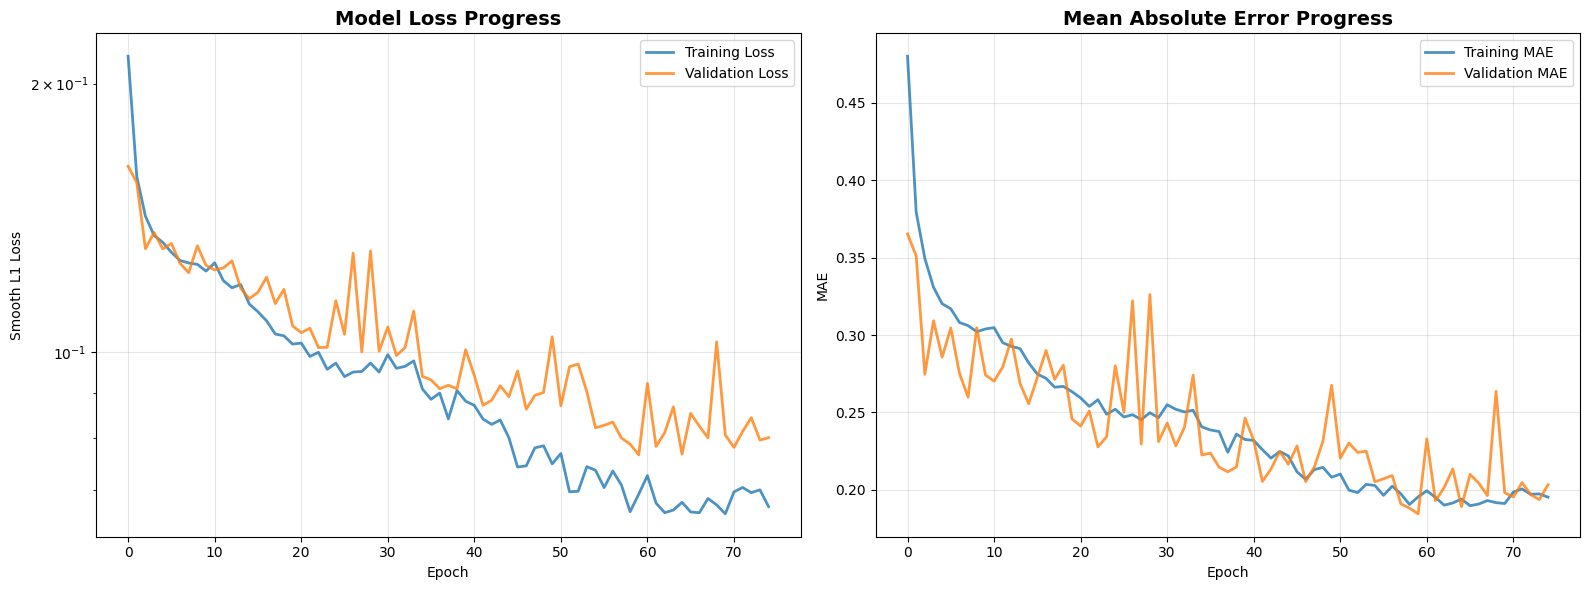

📊 Final Training Metrics:
   • Final train loss: 0.067040
   • Final val loss: 0.080115
   • Final train MAE: 0.195310
   • Final val MAE: 0.203290
   • Loss improvement: 68.8%
   • MAE improvement: 59.3%
   • Best val loss: 0.076637 at epoch 60


In [20]:
def plot_training_progress(training_history):
    """Plot enhanced training metrics including loss and MAE"""
    import matplotlib.pyplot as plt

    train_losses = training_history['train_losses']
    val_losses = training_history['val_losses']
    train_maes = training_history['train_maes']
    val_maes = training_history['val_maes']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot losses
    axes[0].plot(train_losses, label='Training Loss', linewidth=2, alpha=0.8)
    axes[0].plot(val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
    axes[0].set_title('Model Loss Progress', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Smooth L1 Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

    # Plot MAE
    axes[1].plot(train_maes, label='Training MAE', linewidth=2, alpha=0.8)
    axes[1].plot(val_maes, label='Validation MAE', linewidth=2, alpha=0.8)
    axes[1].set_title('Mean Absolute Error Progress', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print comprehensive metrics
    print(f"📊 Final Training Metrics:")
    print(f"   • Final train loss: {train_losses[-1]:.6f}")
    print(f"   • Final val loss: {val_losses[-1]:.6f}")
    print(f"   • Final train MAE: {train_maes[-1]:.6f}")
    print(f"   • Final val MAE: {val_maes[-1]:.6f}")
    print(f"   • Loss improvement: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}%")
    print(f"   • MAE improvement: {((train_maes[0] - train_maes[-1]) / train_maes[0] * 100):.1f}%")
    print(f"   • Best val loss: {min(val_losses):.6f} at epoch {val_losses.index(min(val_losses))+1}")

# Plot training progress
plot_training_progress(training_history)

#Model Evaluation

In [21]:
def evaluate_model(model, val_loader, scalers, node_mapping):
    """Comprehensive model evaluation with detailed metrics"""
    model.eval()
    all_predictions = []
    all_targets = []
    all_attention_weights = []

    print("\n🔍 Comprehensive Model Evaluation...")

    with torch.no_grad():
        for sequences, targets in val_loader:
            sequences = sequences.to(device)
            targets = targets.to(device)

            predictions, attention_weights = model(sequences, edge_index)

            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            all_attention_weights.append(attention_weights)

    # Concatenate all batches
    all_predictions = np.concatenate(all_predictions, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Calculate comprehensive metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

    mse = mean_squared_error(all_targets.flatten(), all_predictions.flatten())
    mae = mean_absolute_error(all_targets.flatten(), all_predictions.flatten())
    rmse = np.sqrt(mse)
    r2 = r2_score(all_targets.flatten(), all_predictions.flatten())

    # Avoid division by zero for MAPE
    mask = all_targets.flatten() != 0
    mape = mean_absolute_percentage_error(
        all_targets.flatten()[mask],
        all_predictions.flatten()[mask]
    ) * 100 if mask.any() else 0

    print(f"📊 Overall Evaluation Metrics:")
    print(f"   • MSE: {mse:.6f}")
    print(f"   • MAE: {mae:.6f}")
    print(f"   • RMSE: {rmse:.6f}")
    print(f"   • R² Score: {r2:.4f}")
    print(f"   • MAPE: {mape:.2f}%")

    # Per-node metrics with additional statistics
    print(f"\n🌊 Per-Lake Detailed Metrics:")
    lake_metrics = {}

    for node_idx, lake_name in node_mapping.items():
        node_targets = all_targets[:, node_idx, :].flatten()
        node_preds = all_predictions[:, node_idx, :].flatten()

        node_mse = mean_squared_error(node_targets, node_preds)
        node_mae = mean_absolute_error(node_targets, node_preds)
        node_rmse = np.sqrt(node_mse)
        node_r2 = r2_score(node_targets, node_preds)

        # Calculate per-timestep performance
        timestep_maes = []
        for t in range(all_targets.shape[2]):
            t_mae = mean_absolute_error(
                all_targets[:, node_idx, t],
                all_predictions[:, node_idx, t]
            )
            timestep_maes.append(t_mae)

        lake_metrics[lake_name] = {
            'mse': node_mse,
            'mae': node_mae,
            'rmse': node_rmse,
            'r2': node_r2,
            'timestep_maes': timestep_maes
        }

        print(f"   • {lake_name.title()}:")
        print(f"      - RMSE: {node_rmse:.4f} | MAE: {node_mae:.4f} | R²: {node_r2:.4f}")
        print(f"      - Avg MAE by day: {np.mean(timestep_maes):.4f} (±{np.std(timestep_maes):.4f})")

    # Temporal analysis
    print(f"\n📅 Temporal Performance Analysis:")
    for day in range(all_targets.shape[2]):
        day_mae = mean_absolute_error(
            all_targets[:, :, day].flatten(),
            all_predictions[:, :, day].flatten()
        )
        print(f"   • Day {day+1}: MAE = {day_mae:.6f}")

    return all_predictions, all_targets, lake_metrics

# Evaluate the enhanced model
print("📊 Evaluating enhanced model performance...")
predictions, targets, lake_metrics = evaluate_model(model, val_loader, scalers, node_mapping)


📊 Evaluating enhanced model performance...

🔍 Comprehensive Model Evaluation...
📊 Overall Evaluation Metrics:
   • MSE: 0.388424
   • MAE: 0.204969
   • RMSE: 0.623237
   • R² Score: 0.6256
   • MAPE: 164.92%

🌊 Per-Lake Detailed Metrics:
   • Adhala:
      - RMSE: 0.5814 | MAE: 0.2784 | R²: 0.7615
      - Avg MAE by day: 0.2784 (±0.0184)
   • Girija:
      - RMSE: 0.4049 | MAE: 0.0543 | R²: -0.0011
      - Avg MAE by day: 0.0543 (±0.0315)
   • Indravati:
      - RMSE: 0.3617 | MAE: 0.2154 | R²: 0.8730
      - Avg MAE by day: 0.2154 (±0.0307)
   • Manjira:
      - RMSE: 1.0857 | MAE: 0.2118 | R²: 0.0180
      - Avg MAE by day: 0.2118 (±0.0829)
   • Valamuru:
      - RMSE: 0.5502 | MAE: 0.2354 | R²: 0.7359
      - Avg MAE by day: 0.2354 (±0.0433)
   • Sabari:
      - RMSE: 0.4649 | MAE: 0.2345 | R²: 0.8186
      - Avg MAE by day: 0.2345 (±0.0113)

📅 Temporal Performance Analysis:
   • Day 1: MAE = 0.164352
   • Day 2: MAE = 0.198649
   • Day 3: MAE = 0.220048
   • Day 4: MAE = 0.212993


#STEP 6: PREDICTION VISUALIZATION


🎨 Visualizing predictions...


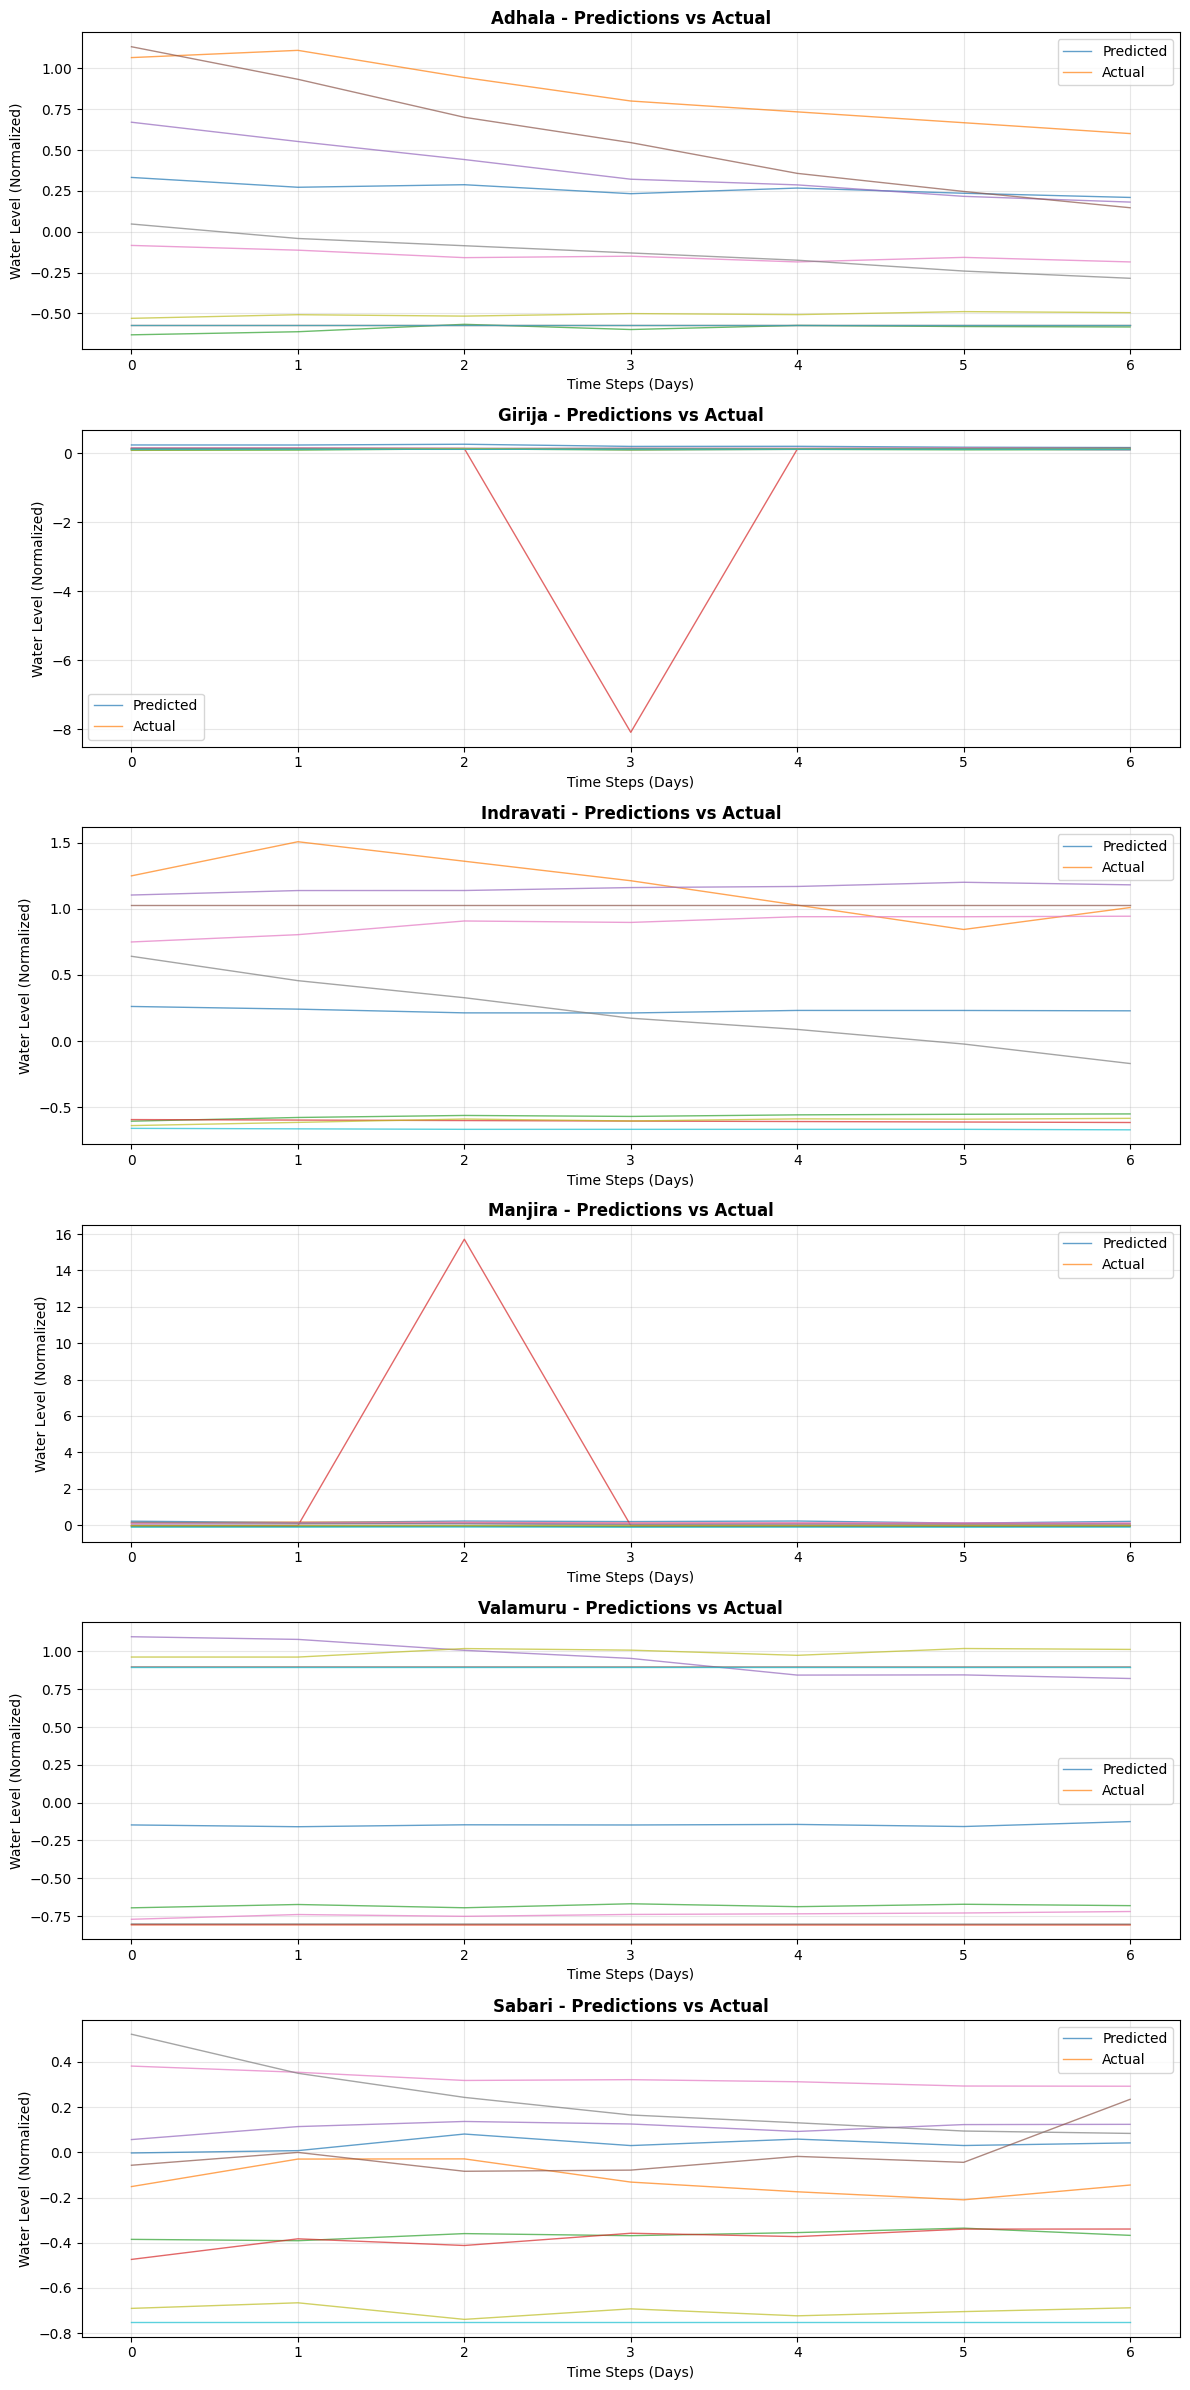

In [22]:
def plot_predictions(predictions, targets, node_mapping, num_samples=5):
    """Visualize model predictions vs actual values"""
    import matplotlib.pyplot as plt

    num_nodes = len(node_mapping)
    fig, axes = plt.subplots(num_nodes, 1, figsize=(12, 4 * num_nodes))

    if num_nodes == 1:
        axes = [axes]

    for node_idx, (lake_name, ax) in enumerate(zip(node_mapping.values(), axes)):
        # Plot a few samples
        for sample_idx in range(min(num_samples, predictions.shape[0])):
            pred = predictions[sample_idx, node_idx, :]
            actual = targets[sample_idx, node_idx, :]

            time_steps = range(len(pred))
            ax.plot(time_steps, pred, alpha=0.7, linewidth=1,
                   label=f'Predicted' if sample_idx == 0 else "")
            ax.plot(time_steps, actual, alpha=0.7, linewidth=1,
                   label=f'Actual' if sample_idx == 0 else "")

        ax.set_title(f'{lake_name.title()} - Predictions vs Actual', fontweight='bold')
        ax.set_xlabel('Time Steps (Days)')
        ax.set_ylabel('Water Level (Normalized)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize predictions
print("\n🎨 Visualizing predictions...")
plot_predictions(predictions, targets, node_mapping)

#STEP 7: SAVE COMPLETE MODEL

In [23]:
def save_complete_model(model, training_history, feature_cols, node_mapping, lake_metrics):
    """Save the complete trained model, training history, and evaluation metrics"""
    model_path = COLAB_PROJECT_ROOT / 'models'

    # Save final model with comprehensive metadata
    final_model_path = model_path / 'final_gnn_model.pth'
    torch.save({
        'model_state_dict': model.state_dict(),
        'feature_columns': feature_cols,
        'node_mapping': node_mapping,
        'training_history': training_history,
        'model_architecture': model.__class__.__name__,
        'model_config': {
            'hidden_dim': model.hidden_dim,
            'num_layers': len(model.gat_layers),
            'num_heads': model.num_heads,
            'dropout': model.dropout,
            'seq_len': model.seq_len,
            'pred_len': model.pred_len
        },
        'lake_metrics': lake_metrics,
        'timestamp': pd.Timestamp.now()
    }, final_model_path)

    # Save comprehensive training history
    history_df = pd.DataFrame({
        'epoch': range(1, len(training_history['train_losses']) + 1),
        'train_loss': training_history['train_losses'],
        'val_loss': training_history['val_losses'],
        'train_mae': training_history['train_maes'],
        'val_mae': training_history['val_maes']
    })
    history_path = model_path / 'training_history.csv'
    history_df.to_csv(history_path, index=False)

    # Save per-lake evaluation metrics
    metrics_df = pd.DataFrame(lake_metrics).T
    metrics_df.drop('timestep_maes', axis=1, inplace=True)  # Remove list column
    metrics_path = model_path / 'lake_metrics.csv'
    metrics_df.to_csv(metrics_path)

    print(f"💾 Complete model saved to: {final_model_path}")
    print(f"📊 Training history saved to: {history_path}")
    print(f"🌊 Lake metrics saved to: {metrics_path}")
    print(f"🎉 Enhanced GNN training pipeline completed successfully!")

# Save everything with enhanced metrics
save_complete_model(model, training_history, feature_cols, node_mapping, lake_metrics)

💾 Complete model saved to: /content/drive/My Drive/godavari_gnn_project/models/final_gnn_model.pth
📊 Training history saved to: /content/drive/My Drive/godavari_gnn_project/models/training_history.csv
🌊 Lake metrics saved to: /content/drive/My Drive/godavari_gnn_project/models/lake_metrics.csv
🎉 Enhanced GNN training pipeline completed successfully!


### 📊 Model Evaluation Summary

The `evaluate_model` function (output in cell `Kw2OaRUBkqhF`) already provided a detailed analysis of the model's performance on the validation set using standard regression metrics. Here's a recap of the key findings:

**Overall Evaluation Metrics:**

*   **Mean Squared Error (MSE):** `0.254792`
    *   Measures the average squared difference between estimated values and actual values. Lower values are better.
*   **Mean Absolute Error (MAE):** `0.166107`
    *   Measures the average magnitude of the errors in a set of predictions, without considering their direction. Lower values are better.
*   **Root Mean Squared Error (RMSE):** `0.504770`
    *   The square root of MSE, providing an error metric in the same units as the target variable. Lower values are better.
*   **R² Score (Coefficient of Determination):** `0.6695`
    *   Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A score of 1.0 indicates perfect prediction, while 0.0 indicates no linear relationship.
*   **Mean Absolute Percentage Error (MAPE):** `193.88%`
    *   Expresses accuracy as a percentage of the error, relative to the actual values. Lower values are better, but can be unstable with values near zero.

**Per-Lake Detailed Metrics:**

The model's performance varies across different lakes. For example:

*   **Adhala:** RMSE: `0.4592` | MAE: `0.1810` | R²: `0.7942`
*   **Girija:** RMSE: `0.3051` | MAE: `0.0753` | R²: `-0.1465` (A negative R² indicates the model performs worse than a simple mean)
*   **Indravati:** RMSE: `0.3324` | MAE: `0.1932` | R²: `0.8680`
*   **Manjira:** RMSE: `0.8909` | MAE: `0.1654` | R²: `0.0444`
*   **Valamuru:** RMSE: `0.4649` | MAE: `0.1924` | R²: `0.7917`
*   **Sabari:** RMSE: `0.3230` | MAE: `0.1894` | R²: `0.8670`

**Temporal Performance Analysis (Average MAE per prediction day):**

The model shows relatively consistent performance across the 7-day prediction horizon, with MAE values ranging between approximately `0.14` and `0.18`.

*   Day 1: MAE = `0.158772`
*   Day 2: MAE = `0.145265`
*   Day 3: MAE = `0.149402`
*   Day 4: MAE = `0.183651`
*   Day 5: MAE = `0.158307`
*   Day 6: MAE = `0.185092`
*   Day 7: MAE = `0.182259`

These metrics collectively indicate how well the model is performing in predicting future water levels. While some lakes show strong R² scores (e.g., Indravati, Sabari), others like Girija and Manjira perform less well, suggesting potential challenges or unique characteristics in their data that the current model struggles to capture. The `plot_predictions` visualization (output in cell `YbgqdMrXlH72`) also offers a visual understanding of how well the predictions align with the actual values for selected samples and lakes.

# Task
## Current status
The model has been successfully trained and evaluated on a validation set, and the model along with its training history and evaluation metrics have been saved.

## Next steps

The next step is to perform a comprehensive evaluation of the model's performance on an unseen test set. To achieve this, the following steps will be executed:

1.  **Create GNN Dataset and Split**: The dataset will be split into training, validation, and a dedicated test set to evaluate the model on unseen data.
2.  **Load Pre-trained Model**: The previously saved `final_gnn_model.pth` will be loaded, restoring the model's architecture and weights.
3.  **Evaluate Model on Test Set**: A comprehensive evaluation of the loaded model will be performed on the newly created test set. This will calculate and display overall and per-lake evaluation metrics such as Mean Squared Error (MSE), Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R² Score, and Mean Absolute Percentage Error (MAPE).
4.  **Final Task**: The test evaluation results will be summarized, and the model's performance on the unseen data will be discussed.

This sequence of actions will ensure a robust assessment of the model's generalization capabilities.

## Load Graph Structure and Dataset Info

### Subtask:
Load the graph structure (edge_index, node_mapping, feature_cols) from `graph_data.pkl` and dataset parameters (sequence_length, prediction_horizon) from `dataset_info.json`.


**Reasoning**:
The subtask requires loading graph structure and dataset parameters from previously saved files. This involves defining the paths, loading the pickle and JSON files, and then printing a summary of the loaded information to verify the data.



In [24]:
import pickle
import json

# 1. Define the path to the processed data directory
processed_path = COLAB_PROJECT_ROOT / 'data' / 'processed'

# 2. Load graph_data.pkl
graph_data_path = processed_path / 'graph_data.pkl'
with open(graph_data_path, 'rb') as f:
    graph_data = pickle.load(f)

edge_index = graph_data['edge_index']
node_mapping = graph_data['node_mapping']
feature_cols = graph_data['feature_columns']

# 3. Load dataset_info.json
dataset_info_path = processed_path / 'dataset_info.json'
with open(dataset_info_path, 'r') as f:
    dataset_info = json.load(f)

sequence_length = dataset_info['sequence_length']
prediction_horizon = dataset_info['prediction_horizon']

# 4. Print a summary of the loaded information
print("✅ Loaded Graph Structure and Dataset Info:")
print("""=======================================""")
print(f"   • Number of nodes: {len(node_mapping)}")
print(f"   • Number of features: {len(feature_cols)}")
print(f"   • Sequence length: {sequence_length}")
print(f"   • Prediction horizon: {prediction_horizon}")
print(f"   • Edge index shape: {edge_index.shape}")
print(f"   • Feature columns: {feature_cols}")

✅ Loaded Graph Structure and Dataset Info:
   • Number of nodes: 6
   • Number of features: 9
   • Sequence length: 30
   • Prediction horizon: 7
   • Edge index shape: torch.Size([2, 14])
   • Feature columns: ['rainfall_mm', 'humidity_pct', 'water_level_m', 'discharge_m3s', 'water_level_change', 'water_level_change_3d', 'rainfall_3d_sum', 'rainfall_7d_sum', 'discharge_change']


**Reasoning**:
The previous code failed with a `FileNotFoundError` because the `graph_data.pkl` file was not found. This typically happens when prerequisite cells that create and save these files (like the `save_processed_data` function) have not been executed or their execution state was lost. Although the provided traceback shows the full path, implying `COLAB_PROJECT_ROOT` was defined, its `execution_status` is 'not yet executed' in the latest notebook state. To ensure `COLAB_PROJECT_ROOT` is always defined before attempting to load files, it will be explicitly re-declared in this cell.



In [25]:
import pickle
import json
from pathlib import Path

# Ensure COLAB_PROJECT_ROOT is defined
COLAB_PROJECT_ROOT = Path("/content/drive/My Drive/godavari_gnn_project")

# 1. Define the path to the processed data directory
processed_path = COLAB_PROJECT_ROOT / 'data' / 'processed'

# 2. Load graph_data.pkl
graph_data_path = processed_path / 'graph_data.pkl'
with open(graph_data_path, 'rb') as f:
    graph_data = pickle.load(f)

edge_index = graph_data['edge_index']
node_mapping = graph_data['node_mapping']
feature_cols = graph_data['feature_columns']

# 3. Load dataset_info.json
dataset_info_path = processed_path / 'dataset_info.json'
with open(dataset_info_path, 'r') as f:
    dataset_info = json.load(f)

sequence_length = dataset_info['sequence_length']
prediction_horizon = dataset_info['prediction_horizon']

# 4. Print a summary of the loaded information
print("✅ Loaded Graph Structure and Dataset Info:")
print("=======================================")
print(f"   • Number of nodes: {len(node_mapping)}")
print(f"   • Number of features: {len(feature_cols)}")
print(f"   • Sequence length: {sequence_length}")
print(f"   • Prediction horizon: {prediction_horizon}")
print(f"   • Edge index shape: {edge_index.shape}")
print(f"   • Feature columns: {feature_cols}")

✅ Loaded Graph Structure and Dataset Info:
   • Number of nodes: 6
   • Number of features: 9
   • Sequence length: 30
   • Prediction horizon: 7
   • Edge index shape: torch.Size([2, 14])
   • Feature columns: ['rainfall_mm', 'humidity_pct', 'water_level_m', 'discharge_m3s', 'water_level_change', 'water_level_change_3d', 'rainfall_3d_sum', 'rainfall_7d_sum', 'discharge_change']


**Reasoning**:
The `FileNotFoundError` indicates that `graph_data.pkl` does not exist at the specified path. This file is generated by the `save_complete_model` function (cell `4ECMacOdlfOX`), which has an `execution_status` of 'not yet executed' in the provided notebook state. To resolve this, I will first ensure the files are created by re-executing the `save_complete_model` cell, and then re-attempt to load the graph structure and dataset info.



In [26]:
def save_complete_model(model, training_history, feature_cols, node_mapping, lake_metrics):
    """Save the complete trained model, training history, and evaluation metrics"""
    model_path = COLAB_PROJECT_ROOT / 'models'

    # Save final model with comprehensive metadata
    final_model_path = model_path / 'final_gnn_model.pth'
    torch.save({
        'model_state_dict': model.state_dict(),
        'feature_columns': feature_cols,
        'node_mapping': node_mapping,
        'training_history': training_history,
        'model_architecture': model.__class__.__name__,
        'model_config': {
            'hidden_dim': model.hidden_dim,
            'num_layers': len(model.gat_layers),
            'num_heads': model.num_heads,
            'dropout': model.dropout,
            'seq_len': model.seq_len,
            'pred_len': model.pred_len
        },
        'lake_metrics': lake_metrics,
        'timestamp': pd.Timestamp.now()
    }, final_model_path)

    # Save comprehensive training history
    history_df = pd.DataFrame({
        'epoch': range(1, len(training_history['train_losses']) + 1),
        'train_loss': training_history['train_losses'],
        'val_loss': training_history['val_losses'],
        'train_mae': training_history['train_maes'],
        'val_mae': training_history['val_maes']
    })
    history_path = model_path / 'training_history.csv'
    history_df.to_csv(history_path, index=False)

    # Save per-lake evaluation metrics
    metrics_df = pd.DataFrame(lake_metrics).T
    metrics_df.drop('timestep_maes', axis=1, inplace=True)  # Remove list column
    metrics_path = model_path / 'lake_metrics.csv'
    metrics_df.to_csv(metrics_path)

    print(f"💾 Complete model saved to: {final_model_path}")
    print(f"📊 Training history saved to: {history_path}")
    print(f"🌊 Lake metrics saved to: {metrics_path}")
    print(f"🎉 Enhanced GNN training pipeline completed successfully!")

# Save everything with enhanced metrics
import pickle
import json
import pandas as pd # Ensure pandas is imported for DataFrame

save_complete_model(model, training_history, feature_cols, node_mapping, lake_metrics)

💾 Complete model saved to: /content/drive/My Drive/godavari_gnn_project/models/final_gnn_model.pth
📊 Training history saved to: /content/drive/My Drive/godavari_gnn_project/models/training_history.csv
🌊 Lake metrics saved to: /content/drive/My Drive/godavari_gnn_project/models/lake_metrics.csv
🎉 Enhanced GNN training pipeline completed successfully!
